# Esercizi 2 — Indici di Posizione, Variabilità, Probabilità, Normale e Forma

## Dataset: `airquality`

Il dataset `airquality` contiene 153 rilevazioni giornaliere sulla qualità dell'aria a New York (maggio-settembre 1973).
Variabili principali:
- `Ozone` — ozono (ppb)
- `Solar.R` — radiazione solare (langley)
- `Wind` — velocità del vento (mph)
- `Temp` — temperatura (°F)
- `Month` — mese (5-9)

**Attenzione:** `Ozone` e `Solar.R` contengono valori mancanti (NA). Dovrai gestirli con `na.rm = TRUE`.

**Obiettivo:** risolvi ogni esercizio scrivendo il codice R nelle celle apposite.

> 🟢 Dopo ogni esercizio trovi una cella **SOLUZIONE** nascosta (collassata).
> Cliccaci sopra per espanderla e confrontare la tua risposta.

In [3]:
# Carichiamo il dataset
data("airquality")

# Esploriamo la struttura
head(airquality)
summary(airquality)
str(airquality)

# Attach per accesso diretto
attach(airquality)

,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


     Ozone           Solar.R           Wind             Temp      
 Min.   :  1.00   Min.   :  7.0   Min.   : 1.700   Min.   :56.00  
 1st Qu.: 18.00   1st Qu.:115.8   1st Qu.: 7.400   1st Qu.:72.00  
 Median : 31.50   Median :205.0   Median : 9.700   Median :79.00  
 Mean   : 42.13   Mean   :185.9   Mean   : 9.958   Mean   :77.88  
 3rd Qu.: 63.25   3rd Qu.:258.8   3rd Qu.:11.500   3rd Qu.:85.00  
 Max.   :168.00   Max.   :334.0   Max.   :20.700   Max.   :97.00  
 NA's   :37       NA's   :7                                       
     Month            Day      
 Min.   :5.000   Min.   : 1.0  
 1st Qu.:6.000   1st Qu.: 8.0  
 Median :7.000   Median :16.0  
 Mean   :6.993   Mean   :15.8  
 3rd Qu.:8.000   3rd Qu.:23.0  
 Max.   :9.000   Max.   :31.0  
                               

'data.frame':	153 obs. of  6 variables:
 $ Ozone  : int  41 36 12 18 NA 28 23 19 8 NA ...
 $ Solar.R: int  190 118 149 313 NA NA 299 99 19 194 ...
 $ Wind   : num  7.4 8 12.6 11.5 14.3 14.9 8.6 13.8 20.1 8.6 ...
 $ Temp   : int  67 72 74 62 56 66 65 59 61 69 ...
 $ Month  : int  5 5 5 5 5 5 5 5 5 5 ...
 $ Day    : int  1 2 3 4 5 6 7 8 9 10 ...


The following objects are masked from airquality (pos = 3):

    Day, Month, Ozone, Solar.R, Temp, Wind




---
## Esercizio 1 — Indici di Posizione su Temp

Analizza la variabile **`Temp`** (temperatura in °F):

1. Calcola **minimo e massimo** di Temp (usa `na.rm = TRUE` se serve)
2. Calcola **media e mediana** di Temp
3. Calcola i **quantili** (0%, 25%, 50%, 75%, 100%)
4. Calcola i **decili** (da 0 a 1 con step 0.1)
5. Usa `summary()` per vedere il riepilogo
6. C'è differenza tra media e mediana? Cosa suggerisce?
7. **Extra:** Calcola la **media armonica** di Temp. Ricorda: $H = \frac{n}{\sum 1/x}$

[1] 56

[1] 97

[1] 77.88235

[1] 79

0%  25%  50%  75% 100% 
  56   72   79   85   97

0%  10%  20%  30%  40%  50%  60%  70%  80%  90% 100% 
56.0 64.2 69.0 74.0 76.8 79.0 81.0 83.0 86.0 90.0 97.0

[1] 76.65733

,ni,fi,Ni,Fi
,<dbl>,<dbl>,<dbl>,<dbl>
"(56,66]",20,0.1307190,20,0.1307190
"(66,76]",40,0.2614379,60,0.3921569
"(76,86]",65,0.4248366,125,0.8169935
"(86,96]",26,0.1699346,151,0.9869281


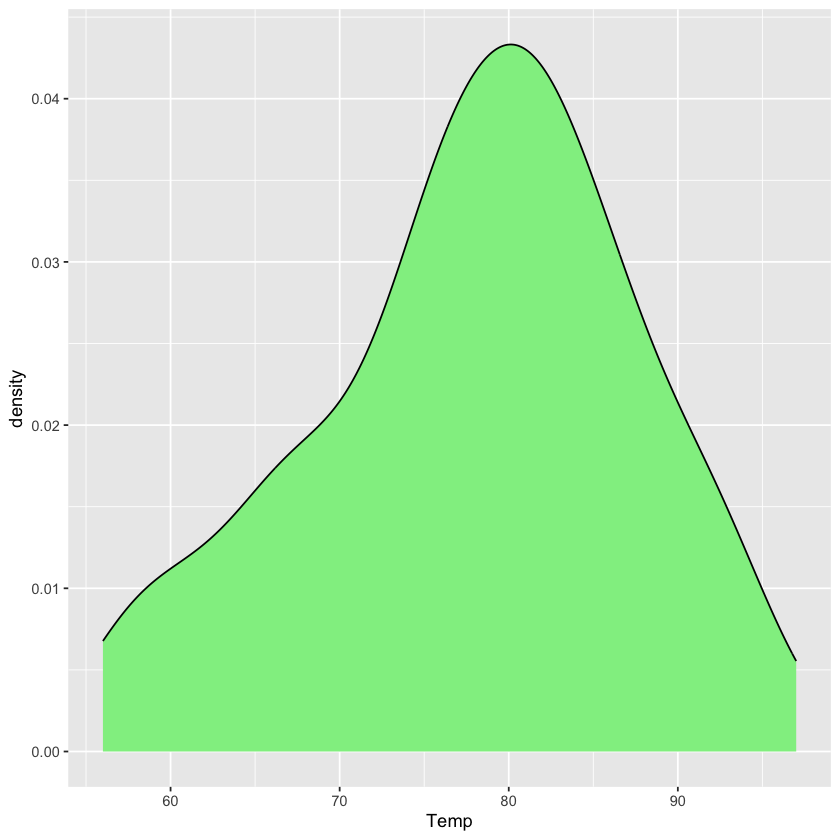

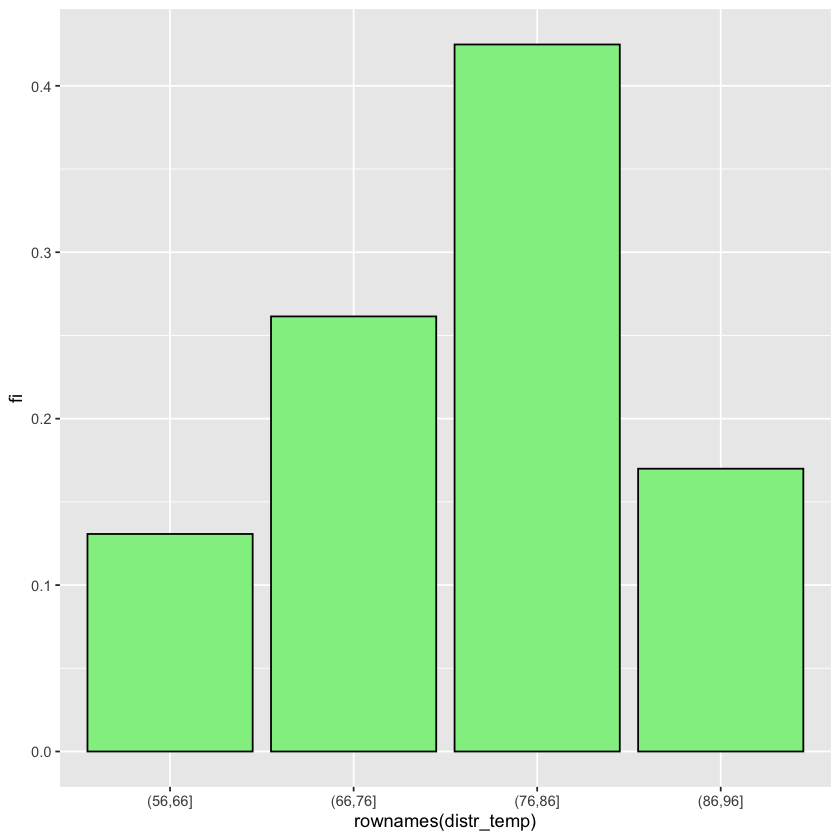

In [46]:
# 👇 Scrivi qui il tuo codice per l'Esercizio 1
min(Temp); max(Temp)
mean(Temp); median(Temp)
quantile(Temp)
quantile(Temp, probs=seq(0,1,0.1))

#yes they are differnt, distrivution is not symmetrical

length(Temp)/sum(1/Temp) # harmonic mean

#some more analysis

library(ggplot2)
ggplot()+
    geom_density(aes(x= Temp), fill = "lightgreen", col = "black")

cl_temp <- cut(Temp, breaks= seq(min(Temp), max(Temp), 10))
n = length(Temp)

distr_temp <-as.data.frame(
    cbind(
        ni = table(cl_temp),
        fi = table(cl_temp)/n,
        Ni = cumsum(table(cl_temp)),
        Fi = cumsum(table(cl_temp))/n
    )
)
distr_temp

ggplot(distr_temp, aes(x= rownames(distr_temp), y = fi)) +
    geom_bar( stat = "identity",
    fill = "lightgreen", col = "black")



In [ ]:
# 🟢 SOLUZIONE Esercizio 1

# 1. Minimo e massimo
min(Temp)
max(Temp)

# 2. Media e mediana
mean(Temp)
median(Temp)

# 3. Quantili
quantile(Temp)

# 4. Decili
quantile(Temp, seq(0, 1, 0.1))

# 5. Summary
summary(Temp)

# 6. Media (77.88) ≈ Mediana (79) -> distribuzione quasi simmetrica

# 7. Media armonica
armonic.mean <- function(x) 1 / (sum(1 / x) / length(x))
armonic.mean(Temp)

---
## Esercizio 2 — Classi e Media Ponderata

Lavoriamo con **`Wind`** (velocità del vento):

1. Raggruppa `Wind` in classi di ampiezza 5 usando `cut()` (da 0 a 25 con step 5)
2. Costruisci una tabella di frequenze completa (ni, fi, Ni, Fi)
3. Aggiungi il centro di classe e calcola la **media ponderata**
4. Confrontala con la media aritmetica semplice
5. **Domanda:** Quale classe ha la frequenza più alta? Quale la più bassa?

In [ ]:
# 👇 Scrivi qui il tuo codice per l'Esercizio 2

In [ ]:
# 🟢 SOLUZIONE Esercizio 2

# 1. Classi di ampiezza 5
Wind_cl <- cut(Wind, seq(0, 25, 5))

# 2. Tabella di frequenze
n <- length(Wind)
distr_freq <- as.data.frame(
  cbind(
    ni = table(Wind_cl),
    fi = table(Wind_cl) / n,
    Ni = cumsum(table(Wind_cl)),
    Fi = cumsum(table(Wind_cl)) / n
  )
)
distr_freq

# 3. Centro di classe e media ponderata
distr_freq$xCi <- seq(2.5, 22.5, 5)
weighted.mean(distr_freq$xCi, distr_freq$ni)

# 4. Confronto con media aritmetica
mean(Wind)

# 5. La classe (5,10] ha la frequenza più alta, (20,25] la più bassa

---
## Esercizio 3 — Misure di Variabilità su Ozone

Analizza la variabile **`Ozone`** (ozono):

1. Calcola il **range** di Ozone (`na.rm = TRUE`)
2. Calcola lo **IQR** di Ozone
3. Calcola **varianza e deviazione standard** a mano (usa `na.rm` e attenzione agli NA)
4. Verifica con `var()` e `sd()`
5. Calcola il **CV** di Ozone
6. Confronta il CV di Ozone con quello di `Wind`. Qual è più variabile in termini relativi?
7. **Extra:** Crea un grafico a punti con ggplot2 dei valori di Ozone ordinati, con linee orizzontali per i quantili

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00   18.00   31.50   42.13   63.25  168.00 

[1] 167

[1] 45.25

[1] 1078.819

[1] 32.84539

[1] 1088.201

[1] 32.98788

[1] 0.7796327

[1] 0.3538032

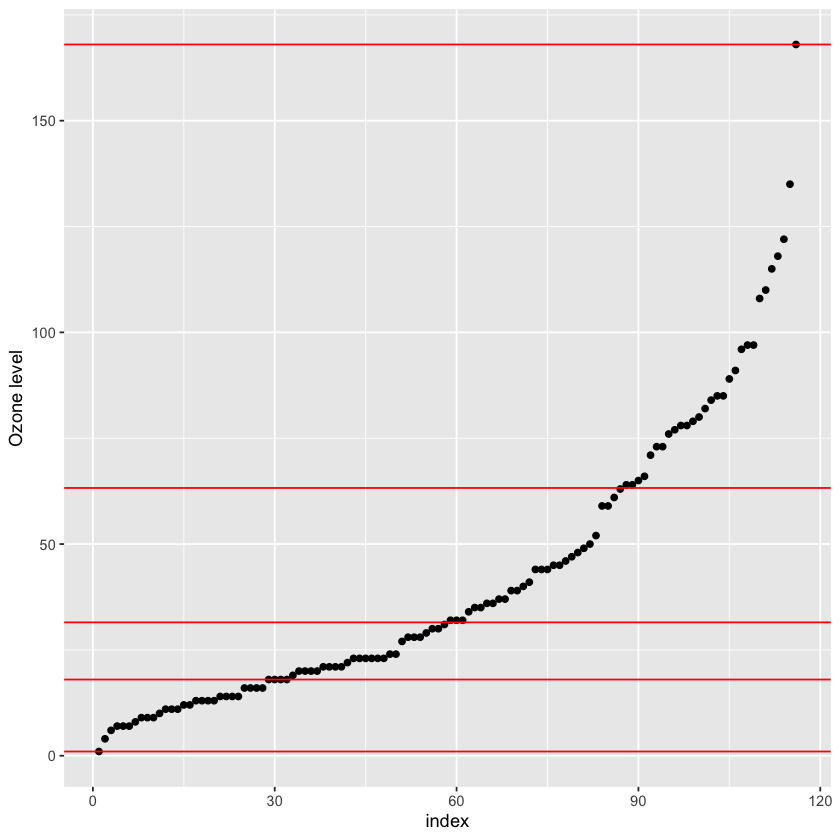

In [79]:
# 👇 Scrivi qui il tuo codice per l'Esercizio 3
summary(Ozone)
Ozone <- na.exclude(Ozone)

max(Ozone, na.rm = TRUE) - min(Ozone, na.rm = TRUE)
IQR(Ozone, na.rm = FALSE)

sig2 <- sum((Ozone - mean(Ozone))^2)/length(Ozone)
sig <- sqrt(sig2)

sig2 ; sig
var(Ozone) ; sd(Ozone)

cv <- sig/mean(Ozone)
cv; sd(Wind)/mean(Wind)

#Ozone is the most variable

ggplot()+
    geom_point(aes(x=seq_along(Ozone),
                   y = sort(Ozone)))+
   geom_hline(yintercept = quantile(Ozone), col = "red")+
   labs(x = "index", y= "Ozone level")


[1]   1 168

[1] 167

[1] 45.25

[1] 1078.819

[1] 32.84539

[1] 1088.201

[1] 32.98788

[1] 78.30151

[1] 35.38032

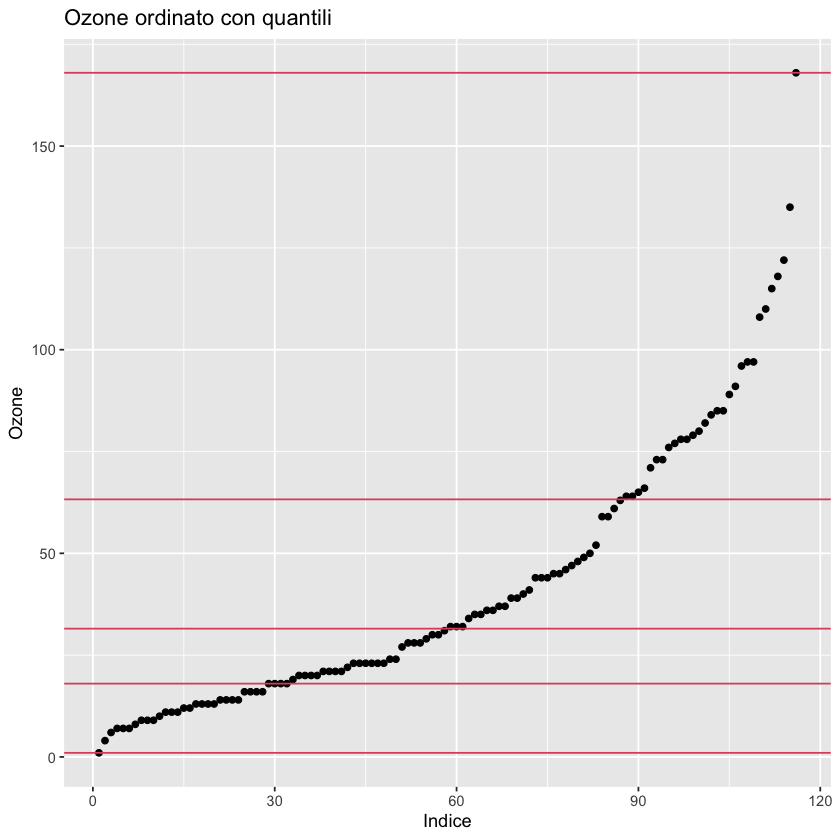

In [80]:
# 🟢 SOLUZIONE Esercizio 3

library(ggplot2)

# 1. Range
range(Ozone, na.rm = TRUE)
max(Ozone, na.rm = TRUE) - min(Ozone, na.rm = TRUE)

# 2. IQR
IQR(Ozone, na.rm = TRUE)

# 3. Varianza e deviazione standard a mano
ozone_clean <- Ozone[!is.na(Ozone)]
mu_oz <- mean(ozone_clean)
n_oz <- length(ozone_clean)
sigma2_oz <- sum((ozone_clean - mu_oz)^2) / n_oz
sigma_oz <- sqrt(sigma2_oz)
sigma2_oz; sigma_oz

# 4. Verifica
var(ozone_clean)
sd(ozone_clean)

# 5. CV di Ozone
CV <- function(x) sd(x) / mean(x) * 100
CV(ozone_clean)

# 6. CV di Wind e confronto
CV(Wind)  # Ozone ha CV molto più alto -> maggiore variabilità relativa

# 7. Extra: grafico a punti con quantili
ggplot() +
  geom_point(aes(x = seq_along(sort(ozone_clean)),
                 y = sort(ozone_clean))) +
  geom_hline(yintercept = quantile(ozone_clean), col = 2) +
  labs(title = "Ozone ordinato con quantili", x = "Indice", y = "Ozone")

---
## Esercizio 4 — Boxplot e dplyr per Mese

1. Crea un **boxplot** di `Temp` raggruppato per `Month` (mese)
2. Crea lo stesso boxplot con **ggplot2**, colorando ogni mese in modo diverso
3. Usa **dplyr** per calcolare media e deviazione standard di Temp per ogni mese
4. Crea un grafico a barre con barre di errore
5. **Domanda:** In quale mese la temperatura media è più alta? E la variabilità più alta?

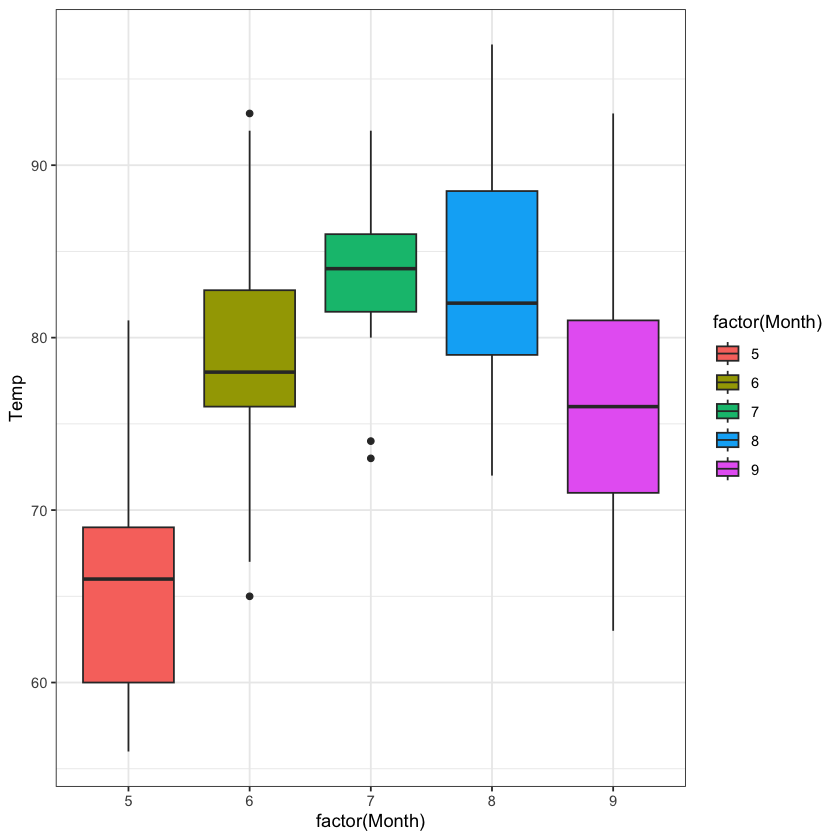

In [90]:
# 👇 Scrivi qui il tuo codice per l'Esercizio 4
ggplot() +
    theme_bw() + 
    geom_boxplot(aes(x = factor(Month), y = Temp, fill = factor(Month)))

You're exactly right on both points. Let me explain.

## Why `factor(Month)` works (and raw `Month` doesn't for a boxplot)

`Month` in the dataset is stored as **numeric** (5, 6, 7, 8, 9). If you do:

```r
geom_boxplot(aes(x = Month, y = Temp))
```

ggplot sees a **continuous numeric** x-axis. It will try to draw **one single boxplot** for the whole range, not separate boxplots per month. It might even give you an error or a weird result.

`factor(Month)` converts it to a **categorical** variable (5, 6, 7, 8, 9 as labels/categories). Now ggplot knows: "draw one boxplot per distinct category". That's what you want.

## Could you use `cut()` instead?

You **could**, but it would be the wrong tool here. Let's see why:

```r
# This would be WRONG for a boxplot:
Month_cut <- cut(Month, breaks = 5:9)  # creates intervals like (5,6], (6,7], etc.
```

`cut()` creates **intervals** (e.g., `(5,6]`), which are still a **single categorical variable** — same as `factor()`. So it would work for grouping, but:

1. **You don't lose info for percentiles/boxplots** — actually, you wouldn't lose anything because `cut()` still just groups the data. The boxplot is computed from the **raw Temp values within each group**, not from the cut labels. So percentiles, IQR, median, etc. are all computed correctly.

2. **But it's unnecessary** — `factor()` is simpler and more direct. `cut()` is designed for **continuous numeric** variables (like Temp, Wind) where you want to bin them into ranges. Month is already discrete (5,6,7,8,9), so `factor()` is the natural choice.

## The key insight: boxplot doesn't use the grouped/cut values

A boxplot works like this:

```
For each group (month 5, month 6, ...):
    take ALL raw Temp values in that group
    compute min, Q1, median, Q3, max from those raw values
    draw the box
```

So even if you used `cut(Month, ...)`, the boxplot would still use the **original Temp values** within each cut group. The cut is just defining **which observations belong to which box**. The statistics (percentiles, etc.) are always computed from the raw data within each group.

## When WOULD you lose info?

You'd lose info if you did what you did earlier with Temp:

```r
cl_temp <- cut(Temp, breaks = seq(min(Temp), max(Temp), 10))
distr_temp <- as.data.frame(table(cl_temp))  # now you only have COUNTS per class
```

Here you **replaced** the raw Temp values with a frequency table. Now you can't compute percentiles anymore because you only have counts per bin, not the original values.

But in the boxplot case, you're NOT replacing anything. You're just telling ggplot: "group by this variable, then compute boxplot statistics from the raw y values within each group". The raw Temp values are still there.

## Summary

| Approach | What happens | Info loss? |
|----------|-------------|------------|
| `factor(Month)` | Groups by month label | No — raw Temp used for stats |
| `cut(Month, ...)` | Groups by interval | No — raw Temp still used |
| `cut(Temp, ...)` then `table()` | Replaces raw values with counts | **Yes** — can't compute percentiles |

So `factor(Month)` is the cleanest way. You're not losing anything — the boxplot is computed from the original Temp values within each month group.

In [ ]:
# 🟢 SOLUZIONE Esercizio 4

library(ggplot2)
library(dplyr)

# 1. Boxplot base
boxplot(Temp ~ Month, main = "Temperatura per mese", col = "lightblue")

# 2. Boxplot con ggplot2
ggplot(data = airquality) +
  geom_boxplot(aes(x = factor(Month), y = Temp, fill = factor(Month))) +
  labs(title = "Temperatura per mese", x = "Mese", y = "Temp (°F)")

# 3. Media e deviazione standard per mese con dplyr
stats_month <- airquality %>%
  group_by(Month) %>%
  summarise(media = mean(Temp), devst = sd(Temp))
stats_month

# 4. Grafico a barre con barre di errore
ggplot(stats_month) +
  theme_bw() +
  geom_col(aes(x = factor(Month), y = media), fill = "black") +
  geom_errorbar(aes(x = factor(Month),
                    ymin = media - devst,
                    ymax = media + devst), col = 2) +
  labs(title = "Temperatura media per mese", x = "Mese", y = "Temp (°F)")

# 5. Mese 7 (Luglio) ha la temperatura media più alta.
#    La variabilità è simile tra i mesi (barre di errore simili).

---
## Esercizio 5 — Indice di Gini su Month

La variabile `Month` indica il mese (5=Maggio, 6=Giugno, ..., 9=Settembre).

1. Calcola la tabella delle frequenze di `Month`
2. Implementa la funzione `gini.index()` e calcola l'indice normalizzato per Month
3. Supponendo che tutti i mesi avessero lo stesso numero di osservazioni, che valore avrebbe l'indice?
4. **Domanda:** I dati sono bilanciati tra i mesi o ci sono mesi sovra/sotto-rappresentati?

In [ ]:
# 👇 Scrivi qui il tuo codice per l'Esercizio 5

In [ ]:
# 🟢 SOLUZIONE Esercizio 5

# 1. Tabella frequenze
table(Month)

# 2. Funzione indice di Gini normalizzato
gini.index <- function(x) {
  ni <- table(x)
  fi <- ni / length(x)
  fi2 <- fi^2
  J <- length(table(x))
  gini <- 1 - sum(fi2)
  gini.norm <- gini / ((J - 1) / J)
  return(gini.norm)
}

# 3. Calcolo
gini.index(Month)

# 4. Se tutti i mesi avessero stesso n, l'indice varrebbe 1 (massima eterogeneità).
#    Il valore reale è vicino a 1 -> i mesi sono abbastanza bilanciati.

---
## Esercizio 6 — Simulazione: Lancio di 3 Dadi

Simula il lancio di **3 dadi** e calcola il **prodotto** dei tre risultati.

1. Scrivi una funzione `lancio3dadi(n)` che restituisce il prodotto di 3 dadi lanciati n volte
2. Esegui n = 100.000
3. Crea un istogramma con ggplot2 (usa `stat = "count"`)
4. **Domanda:** Quali sono i prodotti più frequenti? Perché?

In [ ]:
# 👇 Scrivi qui il tuo codice per l'Esercizio 6

In [ ]:
# 🟢 SOLUZIONE Esercizio 6

library(ggplot2)

# 1. Funzione per il prodotto di 3 dadi
lancio3dadi <- function(n) {
  dado <- 1:6
  prodotto <- sample(dado, n, replace = TRUE) *
              sample(dado, n, replace = TRUE) *
              sample(dado, n, replace = TRUE)
  return(prodotto)
}

# 2. Simulazione
lanci <- lancio3dadi(100000)

# 3. Istogramma
ggplot() +
  geom_histogram(aes(x = lanci),
                 stat = "count",
                 col = "black",
                 fill = "lightblue") +
  labs(title = "Prodotto di 3 dadi (100.000 lanci)",
       x = "Prodotto", y = "Frequenza")

# 4. I prodotti più frequenti sono quelli con fattori piccoli (1,2,3)
#    perché hanno più combinazioni possibili.

---
## Esercizio 7 — Distribuzione Normale per Temp

Verifichiamo se **`Temp`** segue una distribuzione normale.

1. Calcola media e deviazione standard di Temp
2. Usa `pnorm()` per calcolare:
   - P(Temp ≤ 80)
   - P(Temp > 90)
   - P(70 ≤ Temp ≤ 85)
3. Standardizza Temp e calcola le stesse probabilità usando Z e N(0,1)
4. Genera una normale teorica con stessa media e sd e sovrapponila alla densità reale di Temp
5. **Domanda:** Temp ti sembra distribuita normalmente? Perché?

In [ ]:
# 👇 Scrivi qui il tuo codice per l'Esercizio 7

In [ ]:
# 🟢 SOLUZIONE Esercizio 7

# 1. Media e deviazione standard
mu_temp <- mean(Temp)
sd_temp <- sd(Temp)
mu_temp; sd_temp

# 2. Probabilità con pnorm
pnorm(80, mu_temp, sd_temp)  # P(Temp <= 80)
1 - pnorm(90, mu_temp, sd_temp)  # P(Temp > 90)
pnorm(85, mu_temp, sd_temp) - pnorm(70, mu_temp, sd_temp)  # P(70 <= Temp <= 85)

# 3. Standardizzazione e verifica
Z80 <- (80 - mu_temp) / sd_temp
Z90 <- (90 - mu_temp) / sd_temp
Z70 <- (70 - mu_temp) / sd_temp
Z85 <- (85 - mu_temp) / sd_temp

pnorm(Z80, 0, 1)
1 - pnorm(Z90, 0, 1)
pnorm(Z85, 0, 1) - pnorm(Z70, 0, 1)  # stessi risultati

# 4. Sovrapposizione densità
norm_temp <- rnorm(100000, mu_temp, sd_temp)
plot(density(Temp), col = "blue", lwd = 2,
     main = "Temp vs Normale teorica",
     xlab = "Temp (°F)", ylab = "Densità")
lines(density(norm_temp), col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("Temp reale", "Normale teorica"),
       col = c("blue", "red"), lwd = 2, lty = c(1, 2))

# 5. Temp ha una distribuzione quasi normale (leggera asimmetria negativa)

---
## Esercizio 8 — Skewness e Kurtosis per Ozone e Solar.R

Analizziamo la forma delle distribuzioni di **`Ozone`** e **`Solar.R`**.

1. Calcola **asimmetria e curtosi** di Ozone con la funzione del pacchetto `moments` (gestisci gli NA)
2. Calcola asimmetria e curtosi di Solar.R
3. Crea un istogramma (densità) per Ozone con ggplot2
4. Crea un istogramma (densità) per Solar.R
5. Per entrambe, confronta **media e mediana**: cosa indicano sulla simmetria?
6. **Domanda:** Quale delle due variabili è più asimmetrica? Quale ha curtosi più alta?

In [ ]:
# 👇 Scrivi qui il tuo codice per l'Esercizio 8

In [ ]:
# 🟢 SOLUZIONE Esercizio 8

library(ggplot2)
library(moments)

# 1. Asimmetria e curtosi di Ozone (con NA rimossi)
ozone_clean <- Ozone[!is.na(Ozone)]
skewness(ozone_clean)
kurtosis(ozone_clean) - 3

# 2. Asimmetria e curtosi di Solar.R (con NA rimossi)
solar_clean <- Solar.R[!is.na(Solar.R)]
skewness(solar_clean)
kurtosis(solar_clean) - 3

# 3. Istogramma Ozone
ggplot() +
  geom_histogram(aes(x = Ozone, y = stat(density)),
                 col = "lightblue", fill = "lightblue") +
  labs(title = "Distribuzione di Ozone", x = "Ozone (ppb)", y = "Densità")

# 4. Istogramma Solar.R
ggplot() +
  geom_histogram(aes(x = Solar.R, y = stat(density)),
                 col = "lightgreen", fill = "lightgreen") +
  labs(title = "Distribuzione di Solar.R", x = "Solar.R (langley)", y = "Densità")

# 5. Confronto media e mediana
mean(ozone_clean); median(ozone_clean)  # media >> mediana -> forte asimmetria positiva
mean(solar_clean); median(solar_clean)  # media ≈ mediana -> quasi simmetrica

# 6. Ozone è molto più asimmetrica (positiva) e ha curtosi molto più alta di Solar.R